In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, KFold
from sklearn.preprocessing import RobustScaler, OneHotEncoder, PowerTransformer
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from joblib import dump

---
## Load Dataset

In [6]:
df = pd.read_csv('../data/laptop_processed.csv')

In [7]:
df.head()

,Company,Product,TypeName,Inches,OpSys,Price_euros,Cpu_brand,Cpu_model,Cpu_clock_rate_(GHz),Gpu_brand,...,Ips_panel,Touchscreen,Retina_display,PPI,Ram_(GB),Weight_(kg),Memory_SSD_(GB),Memory_HDD_(GB),Memory_Flash_Storage_(GB),Memory_Hybrid_(GB)
0,Apple,MacBook Pro,Ultrabook,13.3,macOS,1339.69,Intel,Core i5,2.3,Intel,...,1.0,0.0,1.0,226.983005,8.0,1.37,128.0,0.0,0.0,0.0
1,Apple,Macbook Air,Ultrabook,13.3,macOS,898.94,Intel,Core i5,1.8,Intel,...,0.0,0.0,0.0,127.677940,8.0,1.34,0.0,0.0,128.0,0.0
2,HP,250 G6,Notebook,15.6,No OS,575.00,Intel,Core i5 7200U,2.5,Intel,...,0.0,0.0,0.0,141.211998,8.0,1.86,256.0,0.0,0.0,0.0
3,Apple,MacBook Pro,Ultrabook,15.4,macOS,2537.45,Intel,Core i7,2.7,AMD,...,1.0,0.0,1.0,220.534624,16.0,1.83,512.0,0.0,0.0,0.0
4,Apple,MacBook Pro,Ultrabook,13.3,macOS,1803.60,Intel,Core i5,3.1,Intel,...,1.0,0.0,1.0,226.983005,8.0,1.37,256.0,0.0,0.0,0.0


---
## Preprocessing

In [8]:
X = df.drop('Price_euros', axis=1)
y = df['Price_euros']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [10]:
string_columns = X.select_dtypes(include=['object']).columns

In [11]:
string_columns

Index(['Company', 'Product', 'TypeName', 'OpSys', 'Cpu_brand', 'Cpu_model',
       'Gpu_brand', 'Gpu_series'],
      dtype='object')

In [12]:
numeric_columns = X.select_dtypes(exclude=['object']).columns

In [13]:
numeric_columns

Index(['Inches', 'Cpu_clock_rate_(GHz)', 'Ips_panel', 'Touchscreen',
       'Retina_display', 'PPI', 'Ram_(GB)', 'Weight_(kg)', 'Memory_SSD_(GB)',
       'Memory_HDD_(GB)', 'Memory_Flash_Storage_(GB)', 'Memory_Hybrid_(GB)'],
      dtype='object')

**Preprocessor for Linear model**

In [14]:
numeric_pipeline = Pipeline(steps=[
    ('scaler', RobustScaler()),
    ('power_transformer', PowerTransformer(method='yeo-johnson'))
])

In [15]:
preprocessor = ColumnTransformer([
    ('string_columns', OneHotEncoder(handle_unknown='ignore'), string_columns),
    ('numeric_columns', numeric_pipeline, numeric_columns)
])

**Preprocessor for Tree based model**

In [16]:
preprocessor_tree = ColumnTransformer([
    ('string_columns', OneHotEncoder(handle_unknown='ignore'), string_columns),
    ('numeric_columns', 'passthrough', numeric_columns)
])

---
## Training base models

In [17]:
def score_calc(cv):
    result = dict()
    
    cv_r2 = cv['test_r2']
    cv_mae = -cv['test_mae']
    cv_rmse = -cv['test_rmse']
    
    result['r2_mean'] = cv_r2.mean()
    result['r2_std'] = cv_r2.std()
    
    result['mae_mean'] = cv_mae.mean()
    result['mae_std'] = cv_mae.std()
    
    result['rmse_mean'] = cv_rmse.mean()
    result['rmse_std'] = cv_rmse.std()
    
    
    return result

In [18]:
def base_model_training(x_data, y_data, preprocessor_step, base_model):
    errors_dict = {
        'r2': 'r2',
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error'
    }
    
    pipe = Pipeline(steps=[
    ('preprocessor', preprocessor_step),
    ('model', base_model)
    ])
    
    wrapped_model = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=101)
    
    cv = cross_validate(
        estimator=wrapped_model,
        X=x_data,
        y=y_data,
        scoring=errors_dict,
        cv=kf,
    )
    
    cv_score = score_calc(cv)
    
    return cv_score 

In [19]:
models = {
    'linear_regression': LinearRegression(),
    'elastic_net': ElasticNet(random_state=101),
    'svr': SVR(max_iter=1_000_000),
    'random_forest': RandomForestRegressor(random_state=101),
    'gradient_boosting': GradientBoostingRegressor(random_state=101),
    'adaboost': AdaBoostRegressor(random_state=101)
}

In [31]:
model_errors = dict()

for name, model in models.items():
    
    
    if name in ['random_forest', 'gradient_boosting', 'adaboost']:
        preprocessor_step = preprocessor_tree
    else:
        preprocessor_step = preprocessor
        
    result = base_model_training(X_train, y_train, preprocessor_step, model)
    
    model_errors[name] = {
        'r2_mean': result['r2_mean'],
        'r2_std': result['r2_std'],
        'mae_mean': result['mae_mean'],
        'mae_std': result['mae_std'],
        'rmse_mean': result['rmse_mean'],
        'rmse_std': result['rmse_std']
    }

In [32]:
errors_df = pd.DataFrame(data=model_errors.values(), index=model_errors.keys())

In [33]:
errors_df

,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
linear_regression,0.750216,0.041512,208.248910,17.358895,341.729427,52.475783
elastic_net,-0.080162,0.051300,518.684323,28.410529,708.996782,59.527361
svr,0.807096,0.061564,178.867061,18.618947,299.579581,70.660874
random_forest,0.807105,0.028688,186.302390,8.132406,300.259276,44.505296
gradient_boosting,0.816695,0.026011,192.398795,15.430144,292.570913,40.738999
adaboost,0.711149,0.043093,249.928234,20.377587,367.007068,50.465009


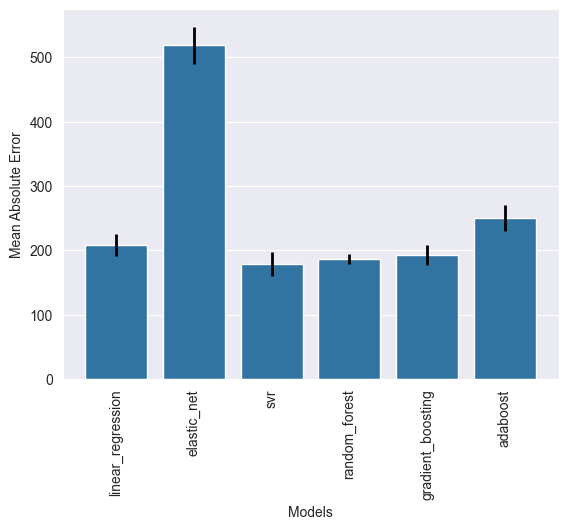

In [34]:
sns.barplot(data=errors_df, x=errors_df.index, y='mae_mean')
plt.errorbar(x=np.arange(len(errors_df)), y=errors_df['mae_mean'], yerr=errors_df['mae_std'], fmt='none', c='black', lw=2)
plt.xlabel("Models")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=90);

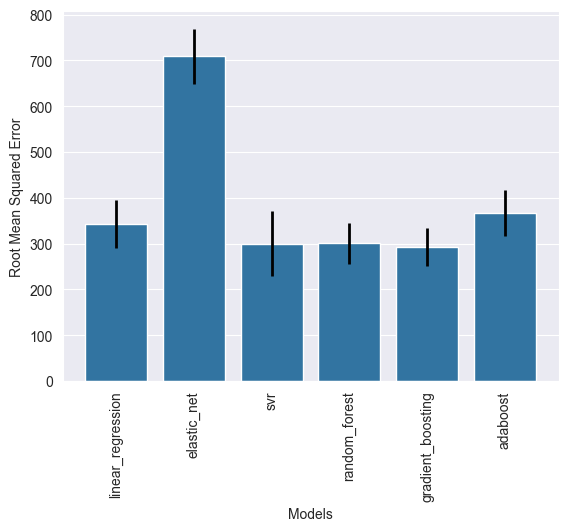

In [35]:
sns.barplot(data=errors_df, x=errors_df.index, y='rmse_mean')
plt.errorbar(x=np.arange(len(errors_df)), y=errors_df['rmse_mean'], yerr=errors_df['rmse_std'], fmt='none', c='black', lw=2)
plt.xlabel("Models")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=90);

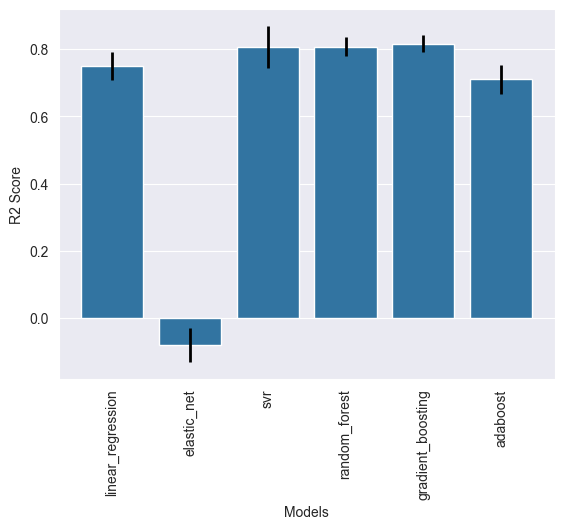

In [36]:
sns.barplot(data=errors_df, x=errors_df.index, y='r2_mean')
plt.errorbar(x=np.arange(len(errors_df)), y=errors_df['r2_mean'], yerr=errors_df['r2_std'], fmt='none', c='black', lw=2)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=90);

**According to the error values and r2 score, three models, svr, random forest and gradient boosting, are selected for tuning.**

---
## Tune Models

In [37]:
def tune_model_training(x_data, y_data, preprocessor_step, tune_model):
    tune_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_step),
        (model_name, tune_model),
    ])
    
    tune_wrapped_model = TransformedTargetRegressor(
        regressor=tune_pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    random_search = RandomizedSearchCV(
        estimator=tune_wrapped_model,
        param_distributions=param_search,
        n_iter=30,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=101,
    )
    
    random_search.fit(x_data, y_data)
    
    return random_search

In [38]:
params_search = {
    'random_forest': {
        'regressor__random_forest__n_estimators': [100, 200, 300, 400],
        'regressor__random_forest__criterion': ["squared_error", "absolute_error", "friedman_mse", "poisson"],
        'regressor__random_forest__max_depth': [None, 10, 20, 30],
        'regressor__random_forest__min_samples_split': [2, 5, 10],
        'regressor__random_forest__max_features': ["sqrt", "log2"],
        'regressor__random_forest__bootstrap': [True, False],
    },
    'gradient_boosting': {
        'regressor__gradient_boosting__n_estimators': [100, 200, 300, 400],
        'regressor__gradient_boosting__learning_rate': np.linspace(0.01, 1, 10),
        'regressor__gradient_boosting__criterion': ['friedman_mse', 'squared_error'],
        'regressor__gradient_boosting__max_depth': [None, 10, 20, 30],
        'regressor__gradient_boosting__min_samples_split': [2, 5, 10],
        'regressor__gradient_boosting__max_features': ["sqrt", "log2"],
    },
    'svr': {
        'regressor__svr__C': np.logspace(-1,1,10),
        'regressor__svr__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'regressor__svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'regressor__svr__degree': [3, 4, 5, 6],
    }
}

In [39]:
tune_models = dict()
tune_scores = dict()

for model_name, param_search in params_search.items():
    if model_name == 'svr':
        preprocessor_step = preprocessor
    else:
        preprocessor_step = preprocessor_tree
        
    tune_model = tune_model_training(X_train, y_train, preprocessor_step, models[model_name])
    
    tune_models[model_name] = tune_model
    tune_scores[model_name] = -tune_model.best_score_

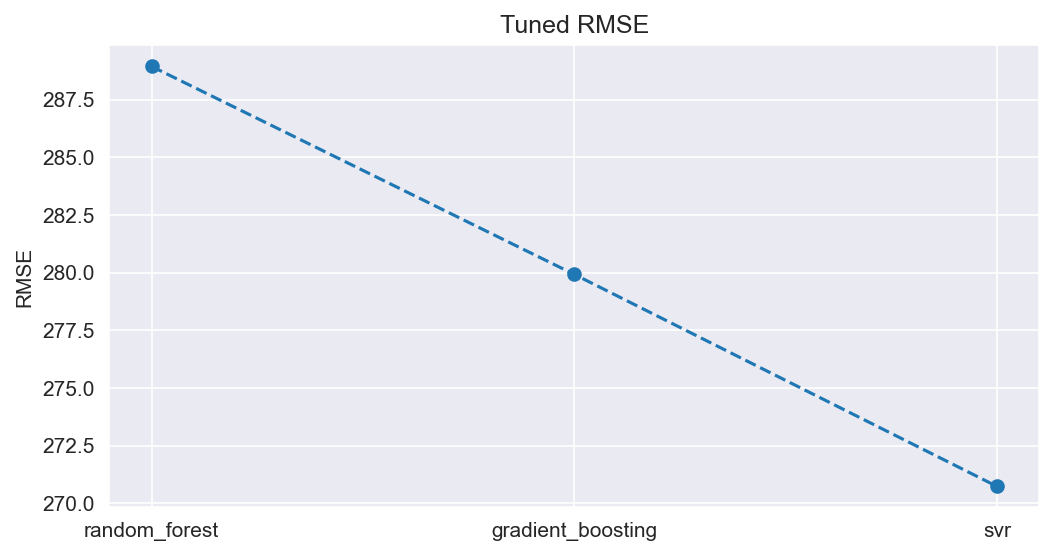

In [56]:
plt.figure(figsize=(8,4), dpi=150)
plt.plot(tune_scores.keys(), tune_scores.values(), 'o--')
plt.title('Tuned RMSE')
plt.ylabel('RMSE');

**In the tune step, the RMSE error value of the SVR model is less than the GradientBoostingRegressor model and RandomForestRegressor model, so we choose the SVR model as the best and final model for this project.**

---
## Best Model Evaluation

In [41]:
best_model = tune_models['svr']

In [43]:
predict = best_model.predict(X_test)

In [49]:
r2 = r2_score(y_test, predict)

In [44]:
mae = mean_absolute_error(y_test, predict)

In [45]:
rmse = np.sqrt(mean_squared_error(y_test, predict))

In [47]:
mape = mean_absolute_percentage_error(y_test, predict)

In [50]:
print(f'r2 score: {r2}\n\
mean absolute error: {mae}\n\
root mean squared error: {rmse}\n\
mean absolute percentage error: {mape}\n')

r2 score: 0.8922844132532285
mean absolute error: 157.45839060752306
root mean squared error: 247.6326654094718
mean absolute percentage error: 0.13781166028867148



In [51]:
residual = y_test - predict

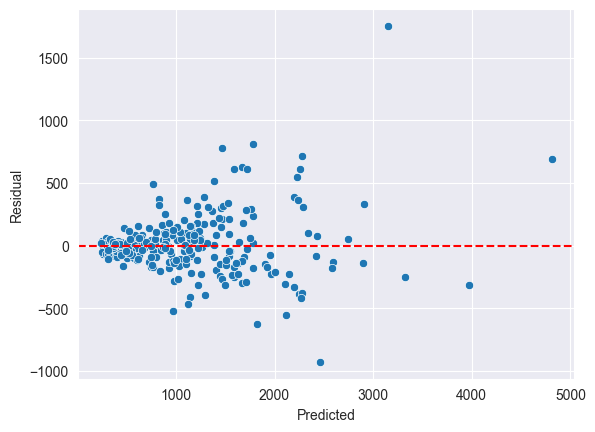

In [52]:
sns.scatterplot(x=predict, y=residual)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual');

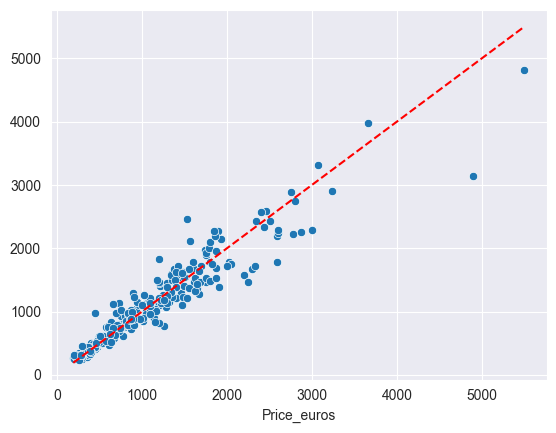

In [53]:
sns.scatterplot(x=y_test, y=predict)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
);

In [54]:
best_model.best_params_

{'regressor__svr__kernel': 'rbf',
 'regressor__svr__gamma': 0.01,
 'regressor__svr__degree': 4,
 'regressor__svr__C': np.float64(3.593813663804626)}

---
## Final Model Training

In [4]:
final_model = SVR(kernel='rbf', gamma=0.01, degree=4, C=3.593813663804626)

In [20]:
final_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('final_model', final_model)
])

In [21]:
final_pipe.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('string_columns',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Company', 'Product', 'TypeName', 'OpSys', 'Cpu_brand', 'Cpu_model',
       'Gpu_brand', 'Gpu_series'],
      dtype='object')),
                                                 ('numeric_columns',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler()),
                                                                  ('power_transformer',
                                                                   PowerTransformer())]),
                                                  Index(['Inches', 'Cpu_clock_rate_(GHz)', 'Ips_panel', 'Touchscreen',
       'Retina_display', 'PPI', 'Ram_(GB)', 'Weight_(kg)', 'Memory_SSD_(GB)',
       'Memory_HDD_(GB)', 'Memory_Flash_Storage_(GB)', 'Memory_Hybrid_(GB)'],
      dtype='object'))])),
                ('final_model',
                 SVR(C=3.593813663804626, degree=4, gamma=0.01))])

## Save Final Model

In [22]:
dump(final_pipe, '../final_model/final_model.pkl')

['../final_model/final_model.pkl']